Dataset Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

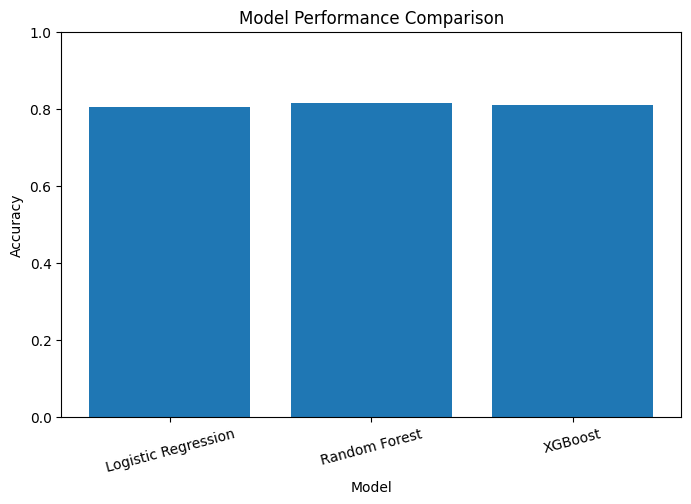

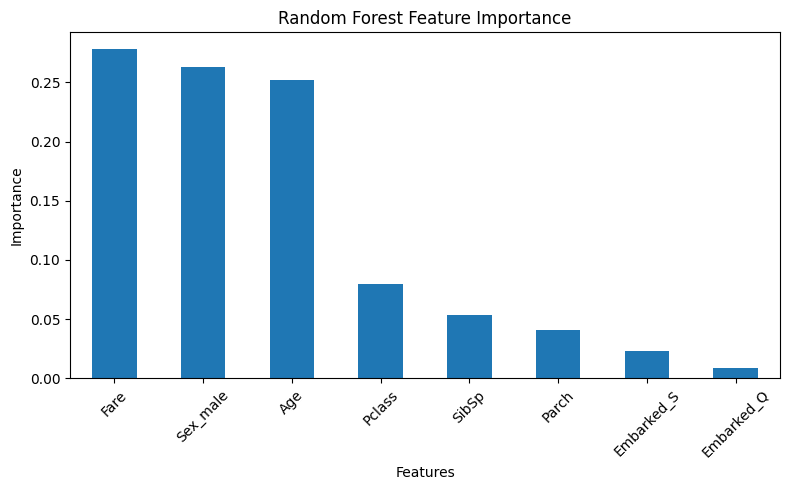

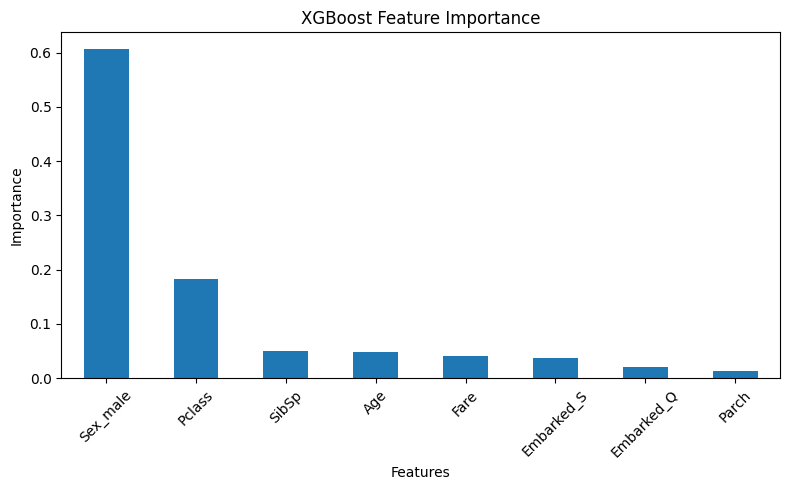


Feature Importance Comparison:
      Feature  Random Forest Importance  XGBoost Importance
4        Fare                  0.278484            0.040979
5    Sex_male                  0.263240            0.606900
1         Age                  0.252361            0.048083
0      Pclass                  0.079478            0.182123
2       SibSp                  0.053489            0.050140
3       Parch                  0.041017            0.013777
7  Embarked_S                  0.023194            0.037613
6  Embarked_Q                  0.008736            0.020386

Top Random Forest Features:
Fare        0.278484
Sex_male    0.263240
Age         0.252361
dtype: float64

Top XGBoost Features:
Sex_male    0.606900
Pclass      0.182123
SibSp       0.050140
dtype: float32


In [1]:
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)
print(df.head())

df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(max_iter=1000, random_state=42)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)

logistic_accuracy = accuracy_score(y_test, logistic_pred)

print("Logistic Regression Accuracy:", logistic_accuracy)
print(classification_report(y_test, logistic_pred))

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_test, rf_pred))

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)
print(classification_report(y_test, xgb_pred))

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Metric': [
        'Accuracy',
        'Accuracy',
        'Accuracy'
    ],
    'Score': [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

print("\nModel Comparison:")
print(comparison)

comparison['Score'] = comparison['Score'].round(4)

comparison.to_csv("model_comparison.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(comparison['Model'], comparison['Score'])
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
rf_importance.plot(kind='bar')
plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
xgb_importance.plot(kind='bar')
plt.title("XGBoost Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

feature_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Random Forest Importance': rf_model.feature_importances_,
    'XGBoost Importance': xgb_model.feature_importances_
})

feature_comparison = feature_comparison.sort_values(
    'Random Forest Importance',
    ascending=False
)

print("\nFeature Importance Comparison:")
print(feature_comparison)

feature_comparison.to_csv(
    "feature_importance_comparison.csv",
    index=False
)

print("\nTop Random Forest Features:")
print(rf_importance.head(3))

print("\nTop XGBoost Features:")
print(xgb_importance.head(3))

In [3]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Metric': ['Accuracy', 'Accuracy', 'Accuracy'],
    'Score': [logistic_accuracy, rf_accuracy, xgb_accuracy]
})

comparison['Score'] = comparison['Score'].round(4)

print("Model Comparison Table:")
display(comparison)

comparison.to_csv("model_comparison.csv", index=False)

Model Comparison Table:


,Model,Metric,Score
0,Logistic Regression,Accuracy,0.8045
1,Random Forest,Accuracy,0.8156
2,XGBoost,Accuracy,0.8101


**How Random Forest and XGBoost differ in how they combine models.**
Ans: Random Forest combines many decision trees by training them independently on different random samples of the data and then combining their predictions through voting. XGBoost builds decision trees sequentially, where each new tree focuses on correcting the errors made by the previous trees. Random Forest mainly reduces overfitting through averaging multiple independent trees, while XGBoost improves performance by continuously learning from previous mistakes. Therefore, XGBoost is often more powerful for complex patterns, while Random Forest is generally simpler and more robust.
